# 1. Project Setup

This notebook performs the initial exploratory analysis (Phase 2A) of the fetal movement dataset.

The objectives of this notebook are to:

- Understand the overall dataset structure.
- Inspect recordings and metadata.
- Analyze recording statistics.
- Check data quality.
- Identify missing values.
- Prepare the dataset for the signal processing pipeline.

This notebook does **not** perform preprocessing or machine learning.

In [ ]:
# ============================================================
# Project Setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

warnings.filterwarnings("ignore")

# Better plotting
plt.style.use("ggplot")
matplotlib.rcParams["figure.figsize"] = (12, 5)

# ------------------------------------------------------------
# Project Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "m873dbhy9j-1"

print("="*60)
print("Fetal Movement Assessment Project")
print("="*60)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Dataset Path : {DATASET_PATH}")

print("\nDataset Exists :", DATASET_PATH.exists())

Fetal Movement Assessment Project
Project Root : c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project
Dataset Path : c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project\data\raw\m873dbhy9j-1

Dataset Exists : True


# 2. Dataset Discovery

This section automatically explores the dataset directory and identifies:

- Files
- Subdirectories
- Metadata files
- Recording folders

This provides an overview of the dataset organization before loading any signals.

In [2]:
# ============================================================
# Dataset Discovery
# ============================================================

all_items = sorted(DATASET_PATH.iterdir())

folders = [item for item in all_items if item.is_dir()]
files = [item for item in all_items if item.is_file()]

print(f"Folders : {len(folders)}")
print(f"Files   : {len(files)}")

Folders : 3
Files   : 4


# 3. Dataset Structure

Each recording folder is inspected to understand:

- Number of recording files
- Metadata files
- File types
- Overall organization

In [3]:
# ============================================================
# Dataset Structure
# ============================================================

for folder in folders:

    print("\n" + "="*60)
    print(folder.name)
    print("="*60)

    contents = sorted(folder.iterdir())

    print(f"Total files : {len(contents)}\n")

    for file in contents[:10]:
        print(file.name)

    if len(contents) > 10:
        print("...")


Sub-dataset One
Total files : 25

record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv
record_14.csv
record_15.csv
record_16.csv
record_17.csv
record_18.csv
...

Sub-dataset Three
Total files : 45

record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv
record_14.csv
record_15.csv
record_16.csv
record_17.csv
record_18.csv
...

Sub-dataset Two
Total files : 39

record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv
record_14.csv
record_15.csv
record_16.csv
record_17.csv
record_18.csv
...


In [ ]:
recording_files = sorted(DATASET_PATH.glob("Sub-dataset Three/record_*.csv"))

print(f"Total Recording Files : {len(recording_files)}")

for file in recording_files[:5]:
    print(file.name)


Total Recording Files : 45
record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv


In [5]:
sample_file = recording_files[1]

print(f"Sample Recording : {sample_file.name}")

df = pd.read_csv(sample_file)

print(df.shape)

display(df.head())

print(sample_file.name)

df = pd.read_csv(sample_file)

print("\nShape")

print(df.shape)

print("\nColumns")

print(df.columns.tolist())

display(df.head())

Sample Recording : record_10.csv
(134145, 26)


,time,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,...,gx3,gy3,gz3,ax4,ay4,az4,gx4,gy4,gz4,label
0,0.000000,14176,5376,6164,-417,247,-178,12444,-5160,8852,...,-826,20,-333,-15380,-2596,3964,-115,32,-345,0
1,0.035117,14100,4896,6260,-485,229,-38,23644,-7488,5756,...,-563,-80,-301,-15540,-3044,4328,-225,134,-286,0
2,0.070752,13848,5280,6436,-290,93,-272,13196,-4456,7456,...,-813,-431,-90,-15320,-2808,4064,-461,48,-303,0
3,0.105906,14504,4764,6308,-437,300,-609,12712,-2744,6740,...,-1101,-626,64,-15080,-2932,4020,-645,175,-322,0
4,0.141654,14036,5312,6584,-291,224,-363,10980,-5776,10000,...,-1257,41,-220,-15116,-2600,3948,-143,51,-305,0


record_10.csv

Shape
(134145, 26)

Columns
['time', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'ax3', 'ay3', 'az3', 'gx3', 'gy3', 'gz3', 'ax4', 'ay4', 'az4', 'gx4', 'gy4', 'gz4', 'label']


,time,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,...,gx3,gy3,gz3,ax4,ay4,az4,gx4,gy4,gz4,label
0,0.000000,14176,5376,6164,-417,247,-178,12444,-5160,8852,...,-826,20,-333,-15380,-2596,3964,-115,32,-345,0
1,0.035117,14100,4896,6260,-485,229,-38,23644,-7488,5756,...,-563,-80,-301,-15540,-3044,4328,-225,134,-286,0
2,0.070752,13848,5280,6436,-290,93,-272,13196,-4456,7456,...,-813,-431,-90,-15320,-2808,4064,-461,48,-303,0
3,0.105906,14504,4764,6308,-437,300,-609,12712,-2744,6740,...,-1101,-626,64,-15080,-2932,4020,-645,175,-322,0
4,0.141654,14036,5312,6584,-291,224,-363,10980,-5776,10000,...,-1257,41,-220,-15116,-2600,3948,-143,51,-305,0


# 4. Recording Statistics

For each recording, we compute:

- Number of samples
- Recording duration
- Number of columns

These statistics provide an overview of the dataset.

In [6]:
# ============================================================
# Recording Statistics
# ============================================================

stats = []

for file in recording_files:

    df = pd.read_csv(file)

    samples = len(df)

    duration = df.iloc[-1, 0] - df.iloc[0, 0]

    stats.append({
        "Recording": file.stem,
        "Samples": samples,
        "Duration (s)": duration,
        "Columns": df.shape[1]
    })

stats_df = pd.DataFrame(stats)

display(stats_df.head(38))

,Recording,Samples,Duration (s),Columns
0,record_1,95043,3262.340535,26
1,record_10,134145,4618.617355,26
2,record_11,93917,3231.760375,26
3,record_12,54528,1874.135585,26
4,record_13,114040,3934.198000,26
5,record_14,126259,4336.880646,26
6,record_15,74781,2571.984773,26
7,record_16,105802,3633.649048,26
8,record_17,136421,4667.985421,26
9,record_18,85059,2933.442620,26


In [7]:
print("="*60)

print("Recording Statistics")

print("="*60)

display(stats_df.describe())

Recording Statistics


,Samples,Duration (s),Columns
count,45.000000,45.000000,45.0
mean,92822.800000,3196.693139,26.0
std,24097.210912,828.018582,0.0
min,34496.000000,1188.310079,26.0
25%,83146.000000,2868.878414,26.0
50%,95043.000000,3273.317575,26.0
75%,107828.000000,3707.554615,26.0
max,136421.000000,4667.985421,26.0


# 5. Missing Value Analysis

Data quality is assessed by checking:

- Missing values
- Duplicate rows
- Infinite values

A clean dataset reduces preprocessing complexity.

In [8]:
# ============================================================
# Missing Values
# ============================================================

quality = []

for file in recording_files:

    df = pd.read_csv(file)

    quality.append({
        "Recording": file.stem,
        "Missing Values": df.isna().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Infinite Values": np.isinf(df.select_dtypes(include=np.number)).sum().sum()
    })

quality_df = pd.DataFrame(quality)

display(quality_df.head())

,Recording,Missing Values,Duplicate Rows,Infinite Values
0,record_1,0,0,0
1,record_10,0,0,0
2,record_11,0,0,0
3,record_12,0,0,0
4,record_13,0,0,0


In [9]:
print("="*60)

print("Dataset Quality Summary")

print("="*60)

print(f"Total Missing Values : {quality_df['Missing Values'].sum()}")

print(f"Total Duplicate Rows : {quality_df['Duplicate Rows'].sum()}")

print(f"Total Infinite Values : {quality_df['Infinite Values'].sum()}")

Dataset Quality Summary
Total Missing Values : 0
Total Duplicate Rows : 0
Total Infinite Values : 0


# 6. Label Analysis

This section analyzes the distribution of fetal movement labels across all recordings.

Objectives:
- Count movement and non-movement samples.
- Measure class imbalance.
- Compute label percentages.
- Analyze label distribution per recording.

In [31]:
# ============================================================
# Locate all recording files
# ============================================================

recording_files = sorted(
    (DATASET_PATH / "Sub-dataset Two").glob("record_*.csv")
)

print(f"Total Recording Files : {len(recording_files)}")

for file in recording_files[:5]:
    print(file.name)

Total Recording Files : 39
record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv


In [32]:
# ============================================================
# Label Distribution
# ============================================================

label_summary = []

for file in recording_files:

    df = pd.read_csv(file)

    movement = (df["label"] == 1).sum()
    no_movement = (df["label"] == 0).sum()

    label_summary.append({
        "Recording": file.stem,
        "Movement": movement,
        "No Movement": no_movement,
        "Total Samples": len(df)
    })

label_df = pd.DataFrame(label_summary)

display(label_df.head(25))

,Recording,Movement,No Movement,Total Samples
0,record_1,63,74899,75468
1,record_10,9,64106,64349
2,record_11,96,23908,24262
3,record_12,123,64968,65249
4,record_13,321,74236,74980
5,record_14,41,57953,58220
6,record_15,154,52428,52934
7,record_16,268,69268,69680
8,record_17,104,57734,58977
9,record_18,137,43582,44010


In [33]:
total_movement = label_df["Movement"].sum()
total_no_movement = label_df["No Movement"].sum()

print("="*60)
print("Overall Label Distribution")
print("="*60)

print(f"Movement Samples     : {total_movement:,}")
print(f"No Movement Samples  : {total_no_movement:,}")

total = total_movement + total_no_movement

print(f"\nMovement %     : {100*total_movement/total:.2f}%")
print(f"No Movement %  : {100*total_no_movement/total:.2f}%")

Overall Label Distribution
Movement Samples     : 4,085
No Movement Samples  : 1,971,368

Movement %     : 0.21%
No Movement %  : 99.79%


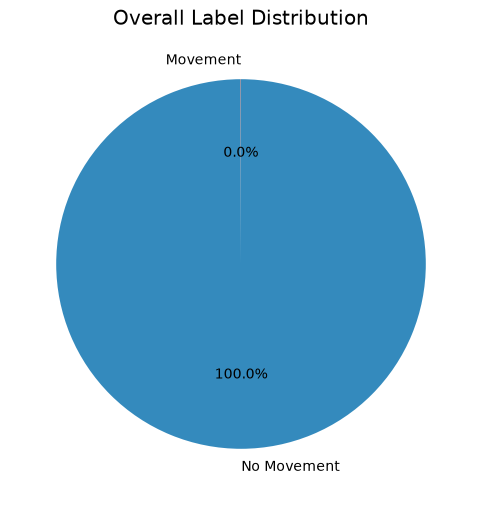

In [23]:
plt.figure(figsize=(6,6))

plt.pie(
    [total_movement, total_no_movement],
    labels=["Movement","No Movement"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Label Distribution")

plt.show()

# 7. Sampling Rate Analysis

The sampling frequency is calculated directly from the timestamps instead of relying on documentation.

In [24]:
# ============================================================
# Sampling Rate Analysis
# ============================================================

sample = pd.read_csv(recording_files[0])

dt = sample["time"].diff().dropna()

sampling_rate = 1 / dt.mean()

print("="*60)
print("Sampling Statistics")
print("="*60)

print(f"Average Δt      : {dt.mean():.6f} sec")
print(f"Sampling Rate   : {sampling_rate:.2f} Hz")

print(f"Minimum Δt      : {dt.min():.6f}")
print(f"Maximum Δt      : {dt.max():.6f}")

Sampling Statistics
Average Δt      : 0.034325 sec
Sampling Rate   : 29.13 Hz
Minimum Δt      : 0.032651
Maximum Δt      : 1.235577


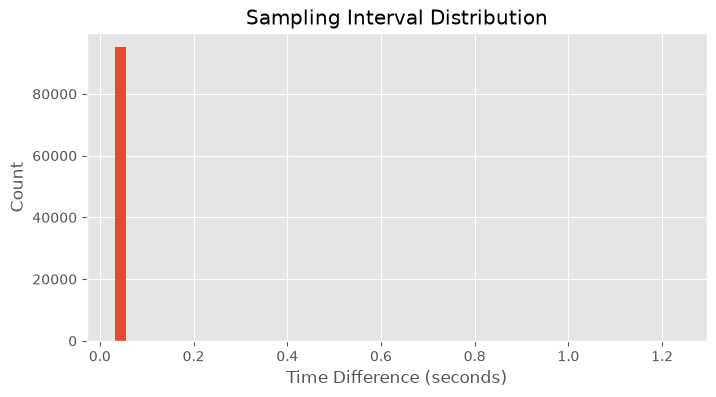

In [25]:
plt.figure(figsize=(8,4))

plt.hist(dt, bins=50)

plt.title("Sampling Interval Distribution")

plt.xlabel("Time Difference (seconds)")
plt.ylabel("Count")

plt.show()

# 8. Signal Visualization

Visualize raw accelerometer signals and overlay fetal movement labels.

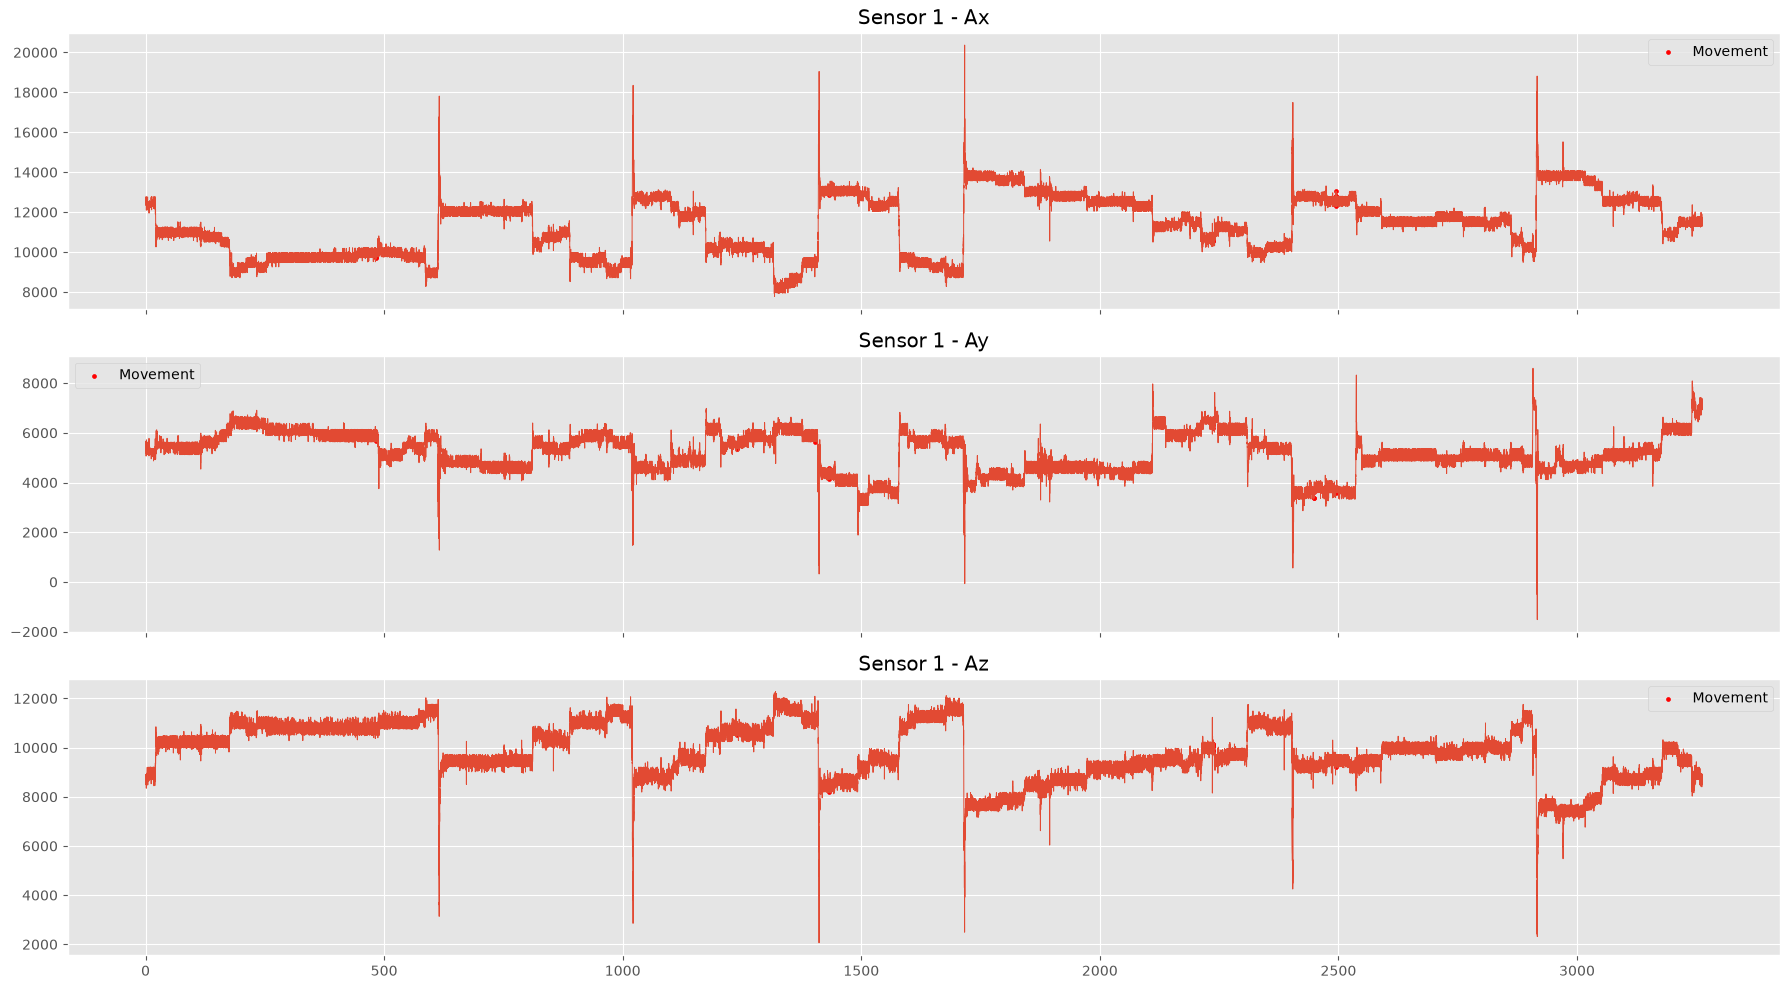

In [26]:
sample = pd.read_csv(recording_files[0])

fig, axes = plt.subplots(3,1, figsize=(18,10), sharex=True)

axes[0].plot(sample["time"], sample["ax1"], linewidth=0.7)
axes[0].set_title("Sensor 1 - Ax")

axes[1].plot(sample["time"], sample["ay1"], linewidth=0.7)
axes[1].set_title("Sensor 1 - Ay")

axes[2].plot(sample["time"], sample["az1"], linewidth=0.7)
axes[2].set_title("Sensor 1 - Az")

movement_idx = sample["label"] == 1

for ax in axes:
    ax.scatter(
        sample.loc[movement_idx,"time"],
        ax.lines[0].get_ydata()[movement_idx],
        s=8,
        c="red",
        label="Movement"
    )
    ax.legend()

plt.tight_layout()
plt.show()

# 9. Sensor Correlation Analysis

Correlation analysis identifies redundant sensors and relationships between channels.

In [27]:
# ============================================================
# Sensor Correlation Analysis
# ============================================================

sample = pd.read_csv(recording_files[0])

sensor_columns = sample.columns.drop(["time", "label"])

corr = sample[sensor_columns].corr()

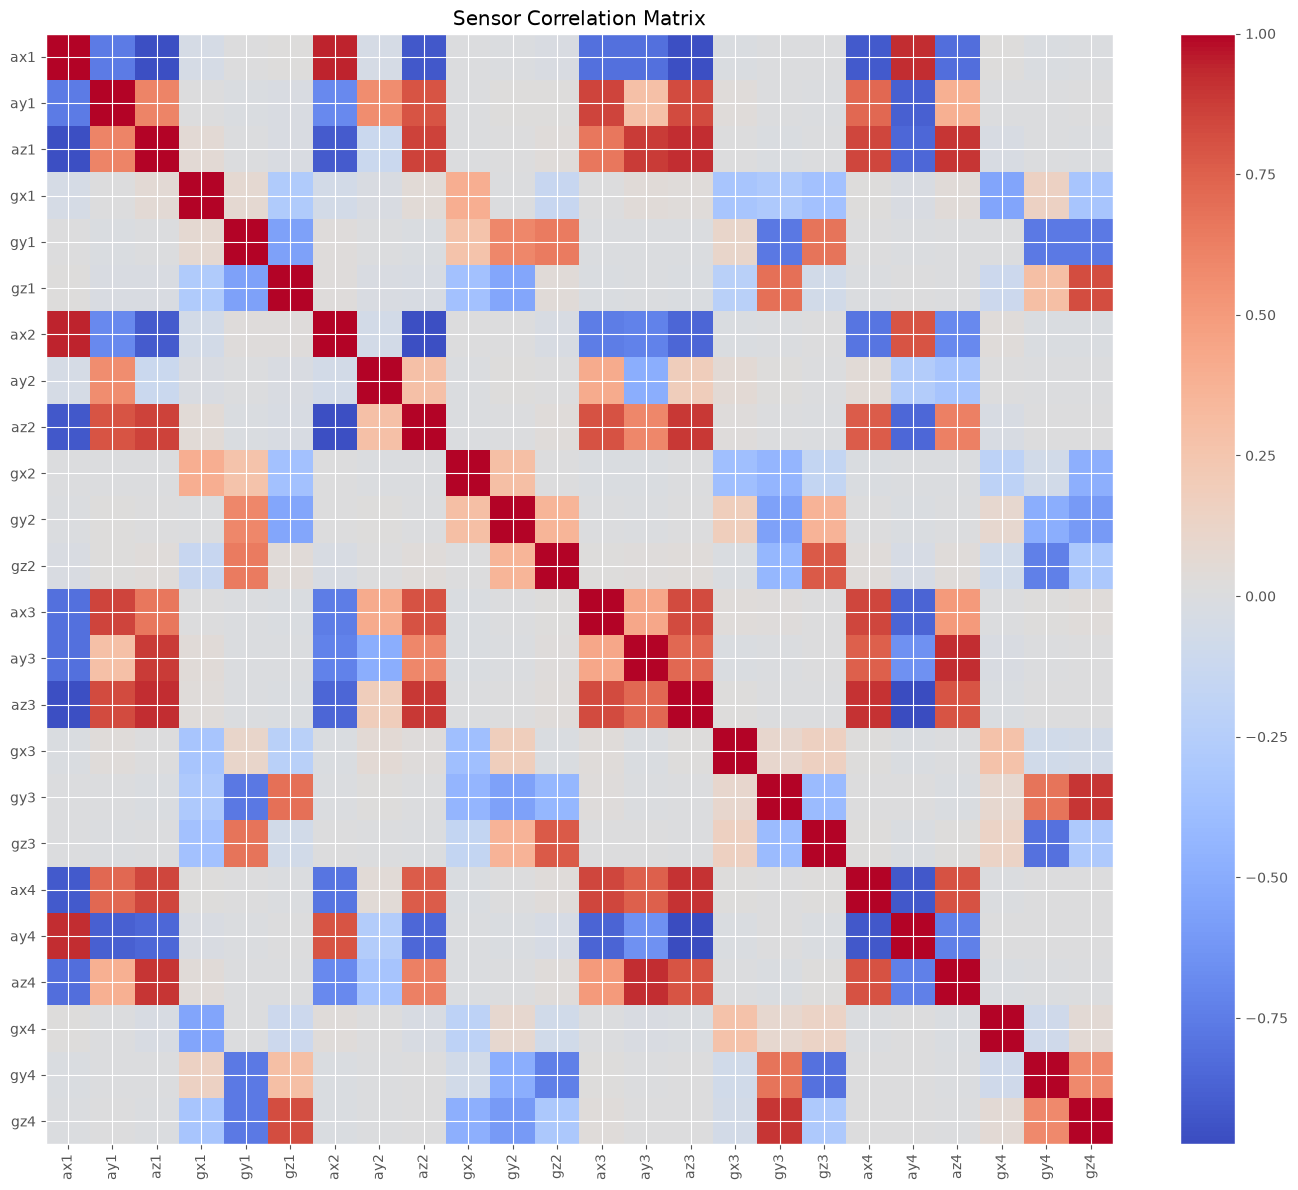

In [28]:
plt.figure(figsize=(14,12))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(range(len(sensor_columns)), sensor_columns, rotation=90)
plt.yticks(range(len(sensor_columns)), sensor_columns)

plt.title("Sensor Correlation Matrix")

plt.tight_layout()

plt.show()

In [29]:
variance = sample[sensor_columns].var().sort_values(ascending=False)

display(variance.to_frame("Variance"))

,Variance
az3,2.951185e+06
az2,2.509538e+06
ax2,2.156250e+06
ax1,2.093078e+06
ay4,1.858517e+06
az1,1.242926e+06
az4,1.149849e+06
ay3,6.508137e+05
ay1,6.273941e+05
ay2,2.775381e+05
